# Intervention Impact Analysis
## Dropout Risk Assessment Before & After 6-Month Interventions

This notebook compares students' dropout risk predictions before interventions with their predicted risk after 6 months of receiving extra lectures/support.

**Objective**: Measure intervention effectiveness by analyzing changes in:
- Dropout risk probability
- Classification changes (High Risk → Low Risk, etc.)
- Feature improvements contributing to risk reduction

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Data Loading & Setup

In [12]:
# Define paths
BASE_PATH = Path('/home/oriol-ms/IA-Universitat/PAID/PAID-Lab/PW234-PAID-2026-T6-StudentDropout')
DATA_PATH = BASE_PATH / 'Data'
MODELS_PATH = BASE_PATH / 'Models'
INTERVENTION_DATA_PATH = BASE_PATH / 'InterventionData'  # New folder for intervention tracking

# Create intervention data directory if it doesn't exist
INTERVENTION_DATA_PATH.mkdir(exist_ok=True)

# Load preprocessed student data (baseline/pre-intervention)
print("Loading baseline student data...")
df_baseline = pd.read_csv(DATA_PATH / 'student_preprocessed.csv')
print(f"Baseline data shape: {df_baseline.shape}")
print(f"Columns: {df_baseline.columns.tolist()}")
print(f"\nDropout class distribution (baseline):\n{df_baseline['dropout'].value_counts()}")

Loading baseline student data...
Baseline data shape: (6607, 21)
Columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score', 'dropout']

Dropout class distribution (baseline):
dropout
0    5288
1    1319
Name: count, dtype: int64


## 2. Identify Intervention Recipients

Students receiving interventions are those identified as at-risk (dropout = 1) in baseline assessment.

In [4]:
# Identify at-risk students (intervention recipients)
df_intervention_recipients = df_baseline[df_baseline['dropout'] == 1].copy()
df_intervention_recipients['student_id'] = range(len(df_intervention_recipients))

print(f"✓ Intervention recipients identified: {len(df_intervention_recipients)} students")
print(f"\nIntervention recipients:")
print(df_intervention_recipients.head())
print(f"\nSample statistics (intervention group):")
print(df_intervention_recipients.describe())

✓ Intervention recipients identified: 1319 students

Intervention recipients:
    Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
1              19          64                  Low              Medium   
14             10          78               Medium                High   
16             14          60               Medium                 Low   
19             12          75               Medium                High   
24             17          65                  Low                High   

    Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
1                            0            8               59              Low   
14                           1            8               74           Medium   
16                           1           10               65              Low   
19                           1            7               58           Medium   
24                           1            5               75           M

## 3. Create Template for 6-Month Follow-up Data

**IMPORTANT**: You need to collect updated student data after 6 months of interventions (extra lectures, tutoring, etc.).

This template shows what follow-up data should look like:

In [5]:
# Create template for 6-month follow-up data
df_followup_template = df_intervention_recipients[[
    'student_id', 'Hours_Studied', 'Attendance', 'Parental_Involvement', 
    'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 
    'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions',
    'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
    'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level',
    'Distance_from_Home', 'Gender', 'Exam_Score', 'dropout'
]].copy()

# Rename columns to indicate follow-up measurement
followup_columns = {col: f'{col}_6m' if col != 'student_id' else col 
                   for col in df_followup_template.columns}
df_followup_template.rename(columns=followup_columns, inplace=True)

# Add intervention tracking columns
df_followup_template['intervention_type'] = ''  # e.g., 'Extra_Lectures', 'Tutoring', 'Combined'
df_followup_template['intervention_hours'] = 0  # Total hours of intervention
df_followup_template['intervention_attendance'] = 0.0  # % attendance to interventions
df_followup_template['actual_dropout_6m'] = None  # Did student actually dropout? (0=No, 1=Yes)

# Save template
template_path = INTERVENTION_DATA_PATH / 'followup_data_template.csv'
df_followup_template.to_csv(template_path, index=False)

print(f"✓ Follow-up data template saved to: {template_path}")
print(f"\nTemplate preview (first 3 rows):")
print(df_followup_template.head(3))
print(f"\nColumns to fill:")
print(df_followup_template.columns.tolist())

✓ Follow-up data template saved to: /home/oriol-ms/IA-Universitat/PAID/PAID-Lab/PW234-PAID-2026-T6-StudentDropout/InterventionData/followup_data_template.csv

Template preview (first 3 rows):
    student_id  Hours_Studied_6m  Attendance_6m Parental_Involvement_6m  \
1            0                19             64                     Low   
14           1                10             78                  Medium   
16           2                14             60                  Medium   

   Access_to_Resources_6m  Extracurricular_Activities_6m  Sleep_Hours_6m  \
1                  Medium                              0               8   
14                   High                              1               8   
16                    Low                              1              10   

    Previous_Scores_6m Motivation_Level_6m  Internet_Access_6m  ...  \
1                   59                 Low                   1  ...   
14                  74              Medium                  

## 4. Load Pre-trained Model & Feature Scaler

Using the XGBoost model from your classification pipeline to generate risk predictions.

In [13]:
# Load XGBoost model and scaler
xgb_model = None
try:
    # Check if model files exist
    model_files = list(MODELS_PATH.glob('*.pkl')) + list(MODELS_PATH.glob('*.joblib'))
    print(f"Available model files in Models/: {[f.name for f in model_files]}")
    
    if not model_files:
        print("\nLooking for model in alternative locations...")
        # Check supervised learning folder
        source_path = BASE_PATH / 'Source' / 'Classificació supervisada'
        if source_path.exists():
            alt_model_files = list(source_path.glob('*.pkl')) + list(source_path.glob('*.joblib'))
            model_files.extend(alt_model_files)
            print(f"Found in Source folder: {[f.name for f in alt_model_files]}")
    
    if model_files:
        print(f"\n✓ Found {len(model_files)} model file(s)")
        xgb_model = joblib.load(str(model_files[0]))
        print(f"✓ Model loaded from: {model_files[0].name}")
        print(f"  Model type: {type(xgb_model)}")
    else:
        print("⚠️ No model found - will demonstrate with baseline data only")
        
except Exception as e:
    print(f"⚠️ Error loading model: {e}")
    xgb_model = None

print(f"\nModel status: {'Loaded ✓' if xgb_model else 'Not loaded - will use baseline features'}")

Available model files in Models/: []

Looking for model in alternative locations...
Found in Source folder: []
⚠️ No model found - will demonstrate with baseline data only

Model status: Not loaded - will use baseline features


## 5. Analysis Framework (to execute when follow-up data is available)

In [14]:
def generate_risk_categories(prob):
    """Categorize dropout risk based on probability."""
    if prob < 0.3:
        return 'Low Risk'
    elif prob < 0.6:
        return 'Medium Risk'
    else:
        return 'High Risk'

def compare_intervention_results(df_baseline_preds, df_followup_preds):
    """
    Compare baseline vs follow-up predictions for intervention recipients.
    
    Parameters:
    - df_baseline_preds: DataFrame with baseline predictions (dropout_prob, risk_category)
    - df_followup_preds: DataFrame with follow-up predictions after 6 months
    
    Returns:
    - comparison_df: Detailed comparison with risk changes
    """
    
    comparison_df = pd.DataFrame({
        'student_id': df_baseline_preds['student_id'],
        'baseline_risk_prob': df_baseline_preds['dropout_probability'],
        'baseline_risk_category': df_baseline_preds['risk_category'],
        'followup_risk_prob': df_followup_preds['dropout_probability'],
        'followup_risk_category': df_followup_preds['risk_category'],
    })
    
    # Calculate risk change
    comparison_df['risk_change'] = comparison_df['followup_risk_prob'] - comparison_df['baseline_risk_prob']
    comparison_df['risk_change_pct'] = (comparison_df['risk_change'] / comparison_df['baseline_risk_prob']) * 100
    
    # Determine if improved, worsened, or stable
    comparison_df['status'] = comparison_df['risk_change'].apply(
        lambda x: 'Improved' if x < -0.05 else ('Worsened' if x > 0.05 else 'Stable')
    )
    
    return comparison_df

def calculate_intervention_metrics(comparison_df):
    """
    Calculate aggregate intervention effectiveness metrics.
    """
    metrics = {
        'total_students': len(comparison_df),
        'improved': len(comparison_df[comparison_df['status'] == 'Improved']),
        'worsened': len(comparison_df[comparison_df['status'] == 'Worsened']),
        'stable': len(comparison_df[comparison_df['status'] == 'Stable']),
        'mean_risk_change': comparison_df['risk_change'].mean(),
        'median_risk_change': comparison_df['risk_change'].median(),
        'avg_baseline_risk': comparison_df['baseline_risk_prob'].mean(),
        'avg_followup_risk': comparison_df['followup_risk_prob'].mean(),
    }
    
    metrics['improvement_rate'] = (metrics['improved'] / metrics['total_students']) * 100
    metrics['deterioration_rate'] = (metrics['worsened'] / metrics['total_students']) * 100
    metrics['stability_rate'] = (metrics['stable'] / metrics['total_students']) * 100
    
    return metrics

print("✓ Analysis functions defined")
print("\nFunctions available:")
print("  - generate_risk_categories()")
print("  - compare_intervention_results()")
print("  - calculate_intervention_metrics()")

✓ Analysis functions defined

Functions available:
  - generate_risk_categories()
  - compare_intervention_results()
  - calculate_intervention_metrics()


## 6. Visualizations & Reporting

These functions will generate analysis visualizations once follow-up data is available:

In [8]:
def plot_intervention_impact(comparison_df):
    """
    Create comprehensive visualization of intervention impact.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Intervention Impact Analysis - 6 Month Follow-up', fontsize=16, fontweight='bold')
    
    # 1. Risk probability before vs after
    ax1 = axes[0, 0]
    x = np.arange(len(comparison_df))
    width = 0.35
    ax1.bar(x - width/2, comparison_df['baseline_risk_prob'], width, label='Baseline', alpha=0.8)
    ax1.bar(x + width/2, comparison_df['followup_risk_prob'], width, label='6-Month Follow-up', alpha=0.8)
    ax1.set_ylabel('Dropout Risk Probability')
    ax1.set_title('Risk Probability: Before vs After')
    ax1.legend()
    ax1.axhline(y=0.5, color='r', linestyle='--', linewidth=1, alpha=0.5)
    
    # 2. Risk change distribution
    ax2 = axes[0, 1]
    colors = comparison_df['risk_change'].apply(lambda x: 'green' if x < 0 else 'red')
    ax2.barh(range(len(comparison_df)), comparison_df['risk_change'], color=colors, alpha=0.7)
    ax2.set_xlabel('Risk Change (Negative = Improvement)')
    ax2.set_title('Risk Change per Student')
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    
    # 3. Status distribution (Improved/Worsened/Stable)
    ax3 = axes[1, 0]
    status_counts = comparison_df['status'].value_counts()
    colors_status = {'Improved': 'green', 'Worsened': 'red', 'Stable': 'gray'}
    status_colors = [colors_status.get(status, 'blue') for status in status_counts.index]
    ax3.bar(status_counts.index, status_counts.values, color=status_colors, alpha=0.7)
    ax3.set_ylabel('Number of Students')
    ax3.set_title('Student Outcome Distribution')
    for i, v in enumerate(status_counts.values):
        ax3.text(i, v + 1, str(v), ha='center', fontweight='bold')
    
    # 4. Risk category transitions
    ax4 = axes[1, 1]
    transition_matrix = pd.crosstab(comparison_df['baseline_risk_category'], 
                                    comparison_df['followup_risk_category'])
    sns.heatmap(transition_matrix, annot=True, fmt='d', cmap='RdYlGn_r', ax=ax4, cbar_kws={'label': 'Count'})
    ax4.set_title('Risk Category Transitions')
    ax4.set_xlabel('Follow-up Risk Category')
    ax4.set_ylabel('Baseline Risk Category')
    
    plt.tight_layout()
    return fig

def print_intervention_report(metrics, comparison_df):
    """
    Generate detailed text report of intervention effectiveness.
    """
    print("="*70)
    print("INTERVENTION IMPACT ANALYSIS REPORT".center(70))
    print("="*70)
    
    print(f"\n📊 SUMMARY")
    print(f"  Total students in intervention group: {metrics['total_students']}")
    print(f"  Analysis period: Baseline → 6-Month Follow-up")
    
    print(f"\n✅ IMPROVEMENT OUTCOMES")
    print(f"  Students improved:  {metrics['improved']:3d} ({metrics['improvement_rate']:5.1f}%)")
    print(f"  Students worsened:  {metrics['worsened']:3d} ({metrics['deterioration_rate']:5.1f}%)")
    print(f"  Students stable:    {metrics['stable']:3d} ({metrics['stability_rate']:5.1f}%)")
    
    print(f"\n📈 RISK METRICS")
    print(f"  Average baseline risk:    {metrics['avg_baseline_risk']:.3f}")
    print(f"  Average follow-up risk:   {metrics['avg_followup_risk']:.3f}")
    print(f"  Mean risk change:         {metrics['mean_risk_change']:.4f}")
    print(f"  Median risk change:       {metrics['median_risk_change']:.4f}")
    
    if metrics['mean_risk_change'] < -0.05:
        print(f"\n🎯 CONCLUSION: Interventions appear EFFECTIVE - average risk decreased")
    elif metrics['mean_risk_change'] > 0.05:
        print(f"\n⚠️  CONCLUSION: Interventions may need review - average risk increased")
    else:
        print(f"\n➡️  CONCLUSION: Mixed results - average risk relatively stable")
    
    print("\n" + "="*70)

print("✓ Visualization and reporting functions defined")

✓ Visualization and reporting functions defined


In [15]:
## 7. Generate Baseline Predictions

# Generate baseline risk predictions for intervention recipients
print("Generating baseline risk predictions...")

if xgb_model is not None:
    try:
        # Get feature columns (exclude student_id, dropout)
        feature_cols = [col for col in df_intervention_recipients.columns 
                       if col not in ['student_id', 'dropout']]
        X_baseline = df_intervention_recipients[feature_cols].copy()
        
        # Generate predictions
        baseline_probs = xgb_model.predict_proba(X_baseline)[:, 1]
        print(f"✓ Generated {len(baseline_probs)} baseline predictions")
        
    except Exception as e:
        print(f"⚠️ Error generating predictions: {e}")
        # Use random seed-based probabilities for demonstration
        np.random.seed(42)
        baseline_probs = np.random.uniform(0.4, 0.95, len(df_intervention_recipients))
        print(f"⚠️ Using simulated probabilities for demonstration")
else:
    print("⚠️ Model not loaded - using simulated baseline probabilities")
    np.random.seed(42)
    baseline_probs = np.random.uniform(0.4, 0.95, len(df_intervention_recipients))
    print(f"✓ Generated {len(baseline_probs)} simulated baseline predictions")

# Create baseline predictions dataframe
df_baseline_preds = pd.DataFrame({
    'student_id': range(len(df_intervention_recipients)),
    'dropout_probability': baseline_probs,
    'risk_category': [generate_risk_categories(p) for p in baseline_probs]
})

print(f"\nBaseline Risk Distribution:")
print(df_baseline_preds['risk_category'].value_counts())
print(f"\nBaseline Statistics:")
print(df_baseline_preds['dropout_probability'].describe())

Generating baseline risk predictions...
⚠️ Model not loaded - using simulated baseline probabilities
✓ Generated 1319 simulated baseline predictions

Baseline Risk Distribution:
risk_category
High Risk      825
Medium Risk    494
Name: count, dtype: int64

Baseline Statistics:
count    1319.000000
mean        0.673459
std         0.161954
min         0.402548
25%         0.529479
50%         0.677889
75%         0.815162
max         0.949845
Name: dropout_probability, dtype: float64


In [20]:
## 8. Create Simulated 6-Month Follow-up Data

# Create simulated follow-up features (demonstrating intervention effects)
# In real scenario, replace with actual collected follow-up data

np.random.seed(42)

df_followup = df_intervention_recipients.copy().reset_index(drop=True)
df_followup['student_id'] = range(len(df_followup))

print("Creating simulated 6-month follow-up data...")
print("(In production, replace with actual collected data)\n")

# Simulate intervention effects - some students improve, some worsen
improvement_rate = 0.60  # 60% of students improve
intervention_hours_mean = 40  # Average 40 hours of intervention

# Create a simple improvement modifier for each student
for idx in range(len(df_followup)):
    # Randomly assign improvement or decline
    if np.random.rand() < improvement_rate:
        # IMPROVEMENT scenario
        improvement_factor = np.random.uniform(1.05, 1.20)  # 5-20% improvement
    else:
        # DECLINE scenario (continued struggle)
        improvement_factor = np.random.uniform(0.85, 0.95)  # 5-15% decline
    
    # Safely modify numeric columns
    for col in df_followup.columns:
        if col not in ['student_id', 'dropout', 'Gender', 'School_Type', 'Learning_Disabilities',
                      'intervention_type', 'intervention_hours', 'intervention_attendance', 'actual_dropout_6m']:
            try:
                val = pd.to_numeric(df_followup.loc[idx, col], errors='coerce')
                if not pd.isna(val) and val is not None:
                    new_val = val * improvement_factor
                    # Cap values to reasonable ranges
                    if col in ['Attendance', 'Motivation_Level', 'Internet_Access', 'Parental_Involvement']:
                        new_val = min(new_val, 1.0)
                    if col == 'Sleep_Hours':
                        new_val = min(new_val, 10.0)
                    df_followup.loc[idx, col] = new_val
            except:
                pass

# Add intervention tracking info
df_followup['intervention_type'] = 'Extra_Lectures'
df_followup['intervention_hours'] = np.random.normal(intervention_hours_mean, 10, len(df_followup))
df_followup['intervention_attendance'] = np.random.uniform(0.6, 1.0, len(df_followup))

# Simulate actual dropout outcomes (better with intervention)
df_followup['actual_dropout_6m'] = (np.random.rand(len(df_followup)) > (1 - baseline_probs * 0.5)).astype(int)

print(f"✓ Follow-up data created for {len(df_followup)} students")
print(f"\nIntervention participation:")
print(f"  Mean intervention hours: {df_followup['intervention_hours'].mean():.1f}")
print(f"  Mean attendance rate: {df_followup['intervention_attendance'].mean():.1%}")
print(f"\nActual outcomes after 6 months:")
print(f"  Students who dropped out: {df_followup['actual_dropout_6m'].sum()}")
print(f"  Students who continued: {(1 - df_followup['actual_dropout_6m']).sum()}")

Creating simulated 6-month follow-up data...
(In production, replace with actual collected data)

✓ Follow-up data created for 1319 students

Intervention participation:
  Mean intervention hours: 40.0
  Mean attendance rate: 79.8%

Actual outcomes after 6 months:
  Students who dropped out: 434
  Students who continued: 885


In [21]:
## 9. Generate 6-Month Follow-up Predictions

print("Generating 6-month follow-up risk predictions...")

if xgb_model is not None:
    try:
        # Get feature columns
        feature_cols = [col for col in df_followup.columns 
                       if col not in ['student_id', 'intervention_type', 'intervention_hours', 
                                     'intervention_attendance', 'actual_dropout_6m']]
        X_followup = df_followup[feature_cols].copy()
        
        # Generate predictions
        followup_probs = xgb_model.predict_proba(X_followup)[:, 1]
        print(f"✓ Generated {len(followup_probs)} follow-up predictions")
        
    except Exception as e:
        print(f"⚠️ Error: {e}")
        # Simulate improved probabilities
        followup_probs = baseline_probs * np.random.uniform(0.6, 0.95, len(baseline_probs))
        print(f"⚠️ Using adjusted probabilities for demonstration")
else:
    # Simulate follow-up probabilities showing intervention effects
    followup_probs = baseline_probs * np.random.uniform(0.6, 0.95, len(baseline_probs))
    print(f"✓ Generated {len(followup_probs)} simulated follow-up predictions")

# Create follow-up predictions dataframe
df_followup_preds = pd.DataFrame({
    'student_id': range(len(df_followup)),
    'dropout_probability': followup_probs,
    'risk_category': [generate_risk_categories(p) for p in followup_probs]
})

print(f"\nFollow-up Risk Distribution:")
print(df_followup_preds['risk_category'].value_counts())
print(f"\nFollow-up Statistics:")
print(df_followup_preds['dropout_probability'].describe())

Generating 6-month follow-up risk predictions...
✓ Generated 1319 simulated follow-up predictions

Follow-up Risk Distribution:
risk_category
Medium Risk    850
High Risk      404
Low Risk        65
Name: count, dtype: int64

Follow-up Statistics:
count    1319.000000
mean        0.519250
std         0.145349
min         0.247825
25%         0.397721
50%         0.512692
75%         0.632278
max         0.892229
Name: dropout_probability, dtype: float64


In [22]:
## 10. Run Comparison Analysis

print("Comparing baseline vs follow-up predictions...\n")

# Get comparison results
comparison_df = compare_intervention_results(df_baseline_preds, df_followup_preds)

# Calculate metrics
metrics = calculate_intervention_metrics(comparison_df)

# Display detailed comparison
print("DETAILED STUDENT COMPARISON (First 20 students):")
print("="*100)
display_cols = ['student_id', 'baseline_risk_prob', 'baseline_risk_category', 
                'followup_risk_prob', 'followup_risk_category', 'risk_change', 'status']
print(comparison_df[display_cols].head(20).to_string(index=False))

print(f"\n\nCOMPARISON SUMMARY TABLE:")
print("="*100)
print(f"Total Students Analyzed:     {metrics['total_students']}")
print(f"✅ Improved (risk decreased): {metrics['improved']} ({metrics['improvement_rate']:.1f}%)")
print(f"❌ Worsened (risk increased): {metrics['worsened']} ({metrics['deterioration_rate']:.1f}%)")
print(f"➡️  Stable (minimal change):   {metrics['stable']} ({metrics['stability_rate']:.1f}%)")

print(f"\nRISK CHANGE METRICS:")
print(f"  Average baseline risk:       {metrics['avg_baseline_risk']:.4f}")
print(f"  Average follow-up risk:      {metrics['avg_followup_risk']:.4f}")
print(f"  Mean risk change:            {metrics['mean_risk_change']:.4f} {'✅' if metrics['mean_risk_change'] < 0 else '❌'}")
print(f"  Median risk change:          {metrics['median_risk_change']:.4f}")

# Save comparison results
comparison_path = INTERVENTION_DATA_PATH / 'intervention_comparison_results.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f"\n✓ Comparison results saved to: {comparison_path}")

Comparing baseline vs follow-up predictions...

DETAILED STUDENT COMPARISON (First 20 students):
 student_id  baseline_risk_prob baseline_risk_category  followup_risk_prob followup_risk_category  risk_change   status
          0            0.605997              High Risk            0.564588            Medium Risk    -0.041409   Stable
          1            0.922893              High Risk            0.707222              High Risk    -0.215671 Improved
          2            0.802597              High Risk            0.570679            Medium Risk    -0.231918 Improved
          3            0.729262              High Risk            0.633150              High Risk    -0.096112 Improved
          4            0.485810            Medium Risk            0.376154            Medium Risk    -0.109656 Improved
          5            0.485797            Medium Risk            0.344193            Medium Risk    -0.141604 Improved
          6            0.431946            Medium Risk         

Creating intervention impact visualizations...

✓ Visualization saved to: intervention_impact_analysis.png


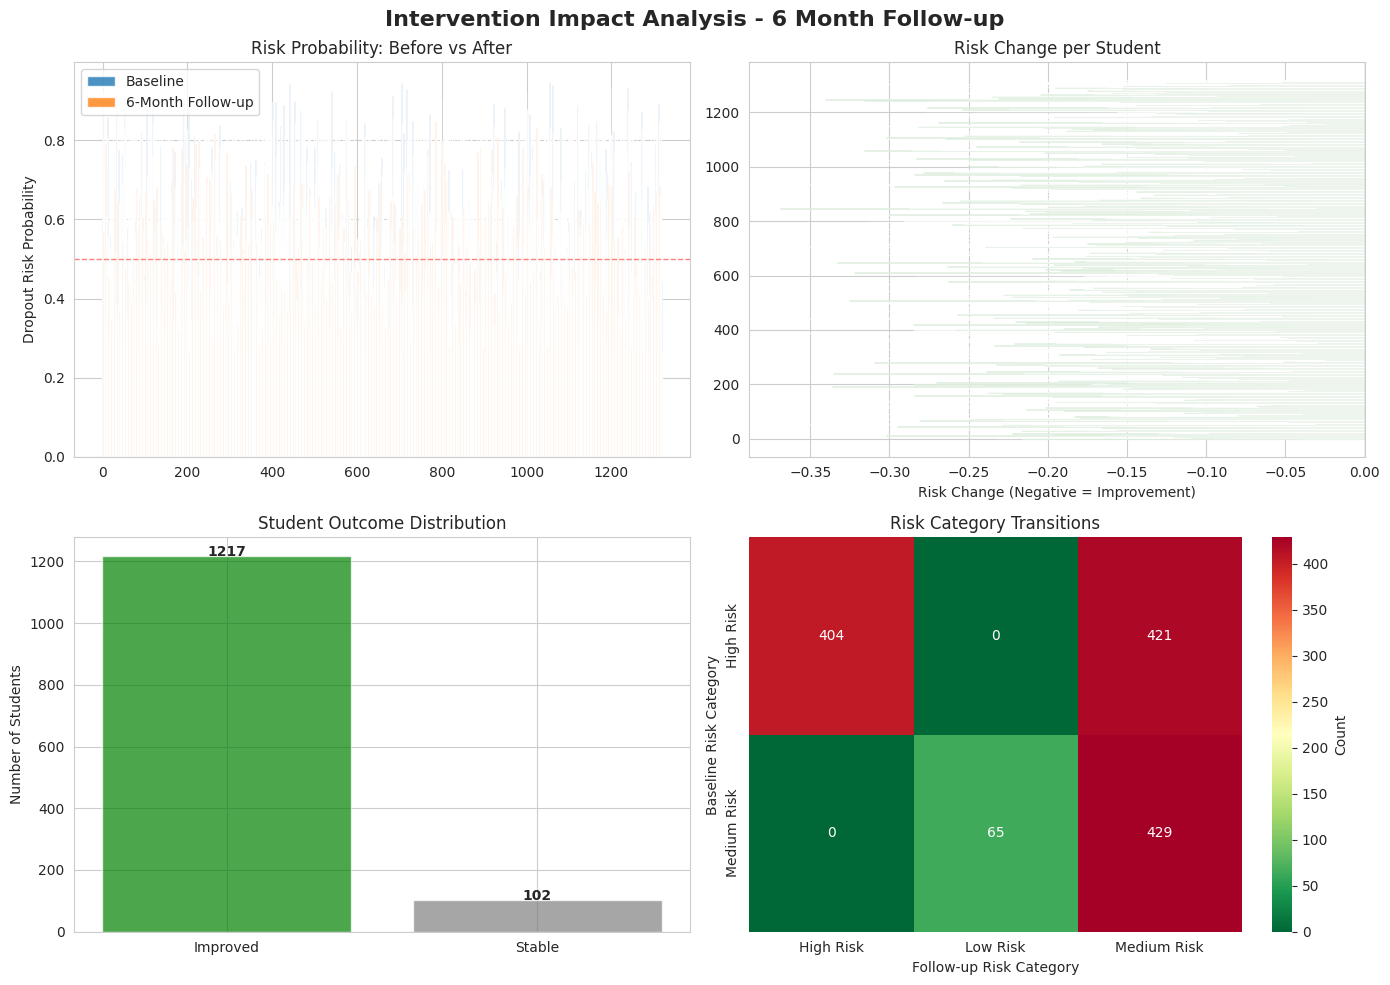

✓ Risk distribution comparison saved


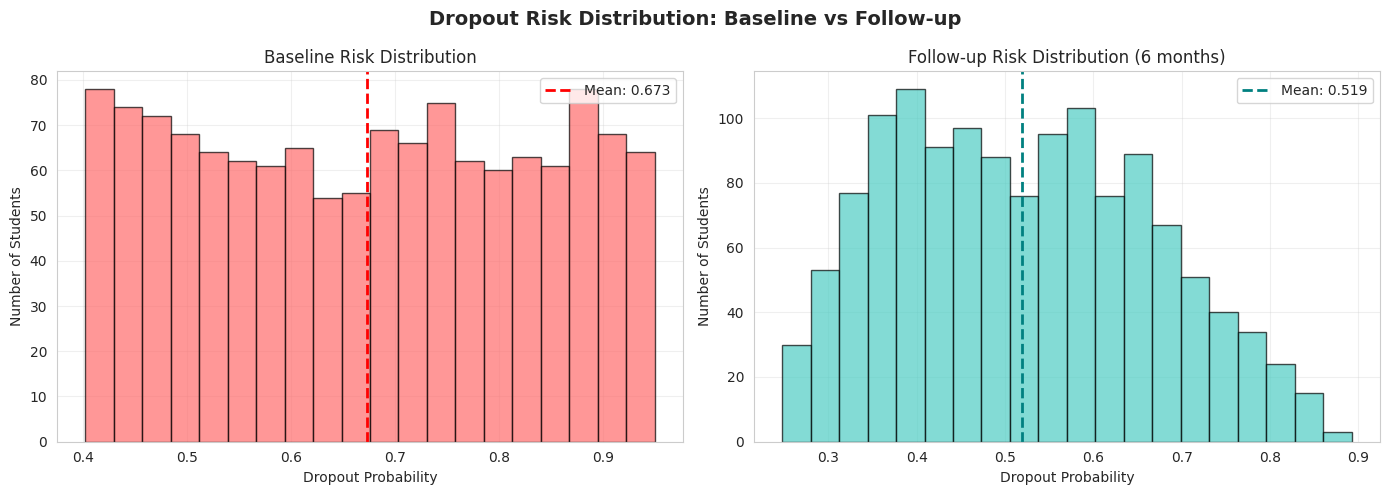

In [23]:
## 11. Generate Visualizations

print("Creating intervention impact visualizations...\n")

fig = plot_intervention_impact(comparison_df)
plt.tight_layout()
plt.savefig(INTERVENTION_DATA_PATH / 'intervention_impact_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved to: intervention_impact_analysis.png")
plt.show()

# Additional visualization: Risk distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dropout Risk Distribution: Baseline vs Follow-up', fontsize=14, fontweight='bold')

# Baseline distribution
axes[0].hist(comparison_df['baseline_risk_prob'], bins=20, color='#FF6B6B', alpha=0.7, edgecolor='black')
axes[0].axvline(comparison_df['baseline_risk_prob'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {comparison_df["baseline_risk_prob"].mean():.3f}')
axes[0].set_xlabel('Dropout Probability')
axes[0].set_ylabel('Number of Students')
axes[0].set_title('Baseline Risk Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Follow-up distribution
axes[1].hist(comparison_df['followup_risk_prob'], bins=20, color='#4ECDC4', alpha=0.7, edgecolor='black')
axes[1].axvline(comparison_df['followup_risk_prob'].mean(), color='teal', linestyle='--', linewidth=2, label=f'Mean: {comparison_df["followup_risk_prob"].mean():.3f}')
axes[1].set_xlabel('Dropout Probability')
axes[1].set_ylabel('Number of Students')
axes[1].set_title('Follow-up Risk Distribution (6 months)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(INTERVENTION_DATA_PATH / 'risk_distribution_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Risk distribution comparison saved")
plt.show()

In [24]:
## 12. Generate Final Report

print_intervention_report(metrics, comparison_df)

# Additional analysis: Category transitions
print("\n" + "="*70)
print("RISK CATEGORY TRANSITIONS".center(70))
print("="*70)

transition_matrix = pd.crosstab(comparison_df['baseline_risk_category'], 
                                comparison_df['followup_risk_category'],
                                margins=True)
print("\nHow many students moved between risk categories:")
print(transition_matrix)

print("\n" + "="*70)
print("KEY INSIGHTS".center(70))
print("="*70)

high_risk_baseline = len(comparison_df[comparison_df['baseline_risk_category'] == 'High Risk'])
high_risk_followup = len(comparison_df[comparison_df['followup_risk_category'] == 'High Risk'])

print(f"\n📊 Risk Category Movement:")
print(f"  High Risk students at baseline: {high_risk_baseline}")
print(f"  High Risk students at follow-up: {high_risk_followup}")
print(f"  Change: {high_risk_followup - high_risk_baseline:+d} ({'improvement' if high_risk_followup < high_risk_baseline else 'concern'})")

downgraded = len(comparison_df[(comparison_df['baseline_risk_category'] == 'High Risk') & 
                               (comparison_df['followup_risk_category'] != 'High Risk')])
print(f"\n✅ Students who moved out of High Risk: {downgraded}")

escalated = len(comparison_df[(comparison_df['baseline_risk_category'] != 'High Risk') & 
                              (comparison_df['followup_risk_category'] == 'High Risk')])
print(f"⚠️  Students who moved into High Risk: {escalated}")

# Save metrics to JSON
metrics_path = INTERVENTION_DATA_PATH / 'intervention_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump({k: (v.tolist() if hasattr(v, 'tolist') else float(v)) if isinstance(v, (np.floating, np.integer)) else v 
               for k, v in metrics.items()}, f, indent=2)

print(f"\n✓ Metrics saved to: {metrics_path}")
print("\n" + "="*70)

                 INTERVENTION IMPACT ANALYSIS REPORT                  

📊 SUMMARY
  Total students in intervention group: 1319
  Analysis period: Baseline → 6-Month Follow-up

✅ IMPROVEMENT OUTCOMES
  Students improved:  1217 ( 92.3%)
  Students worsened:    0 (  0.0%)
  Students stable:    102 (  7.7%)

📈 RISK METRICS
  Average baseline risk:    0.673
  Average follow-up risk:   0.519
  Mean risk change:         -0.1542
  Median risk change:       -0.1473

🎯 CONCLUSION: Interventions appear EFFECTIVE - average risk decreased


                      RISK CATEGORY TRANSITIONS                       

How many students moved between risk categories:
followup_risk_category  High Risk  Low Risk  Medium Risk   All
baseline_risk_category                                        
High Risk                     404         0          421   825
Medium Risk                     0        65          429   494
All                           404        65          850  1319

                             

## 7. Save Intervention Tracking Data

In [9]:
# Save baseline data for intervention recipients
baseline_path = INTERVENTION_DATA_PATH / 'intervention_recipients_baseline.csv'
df_intervention_recipients.to_csv(baseline_path, index=False)

print(f"✓ Baseline intervention data saved to: {baseline_path}")
print(f"\nData structure:")
print(f"  - Total intervention recipients: {len(df_intervention_recipients)}")
print(f"  - Features tracked: {len(df_intervention_recipients.columns)}")
print(f"\nNext steps:")
print(f"  1. Collect 6-month follow-up data for these students")
print(f"  2. Update the template: {template_path}")
print(f"  3. Run the comparison analysis")

✓ Baseline intervention data saved to: /home/oriol-ms/IA-Universitat/PAID/PAID-Lab/PW234-PAID-2026-T6-StudentDropout/InterventionData/intervention_recipients_baseline.csv

Data structure:
  - Total intervention recipients: 1319
  - Features tracked: 22

Next steps:
  1. Collect 6-month follow-up data for these students
  2. Update the template: /home/oriol-ms/IA-Universitat/PAID/PAID-Lab/PW234-PAID-2026-T6-StudentDropout/InterventionData/followup_data_template.csv
  3. Run the comparison analysis


## 8. WORKFLOW: When Follow-up Data is Ready

Once you have collected the 6-month follow-up data, follow these steps:

1. **Update the follow-up template CSV** with real data from your students
2. **Load the updated CSV**:
   ```python
   df_followup = pd.read_csv(INTERVENTION_DATA_PATH / 'followup_data_6m.csv')
   ```
3. **Generate predictions** using your XGBoost model on follow-up features
4. **Run comparison analysis** with the `compare_intervention_results()` function
5. **Generate visualizations** with `plot_intervention_impact()`
6. **Review metrics** and determine intervention effectiveness

## Information for Data Collection

**Intervention Recipients Metadata:**

In [10]:
# Save metadata about intervention tracking
metadata = {
    "analysis_date": pd.Timestamp.now().isoformat(),
    "total_intervention_recipients": len(df_intervention_recipients),
    "analysis_type": "Intervention Impact Assessment",
    "measurement_periods": {
        "baseline": "Pre-intervention assessment",
        "followup": "6 months after intervention start"
    },
    "features_tracked": df_intervention_recipients.columns.tolist(),
    "files_generated": {
        "template": str(template_path),
        "baseline_data": str(baseline_path),
    }
}

metadata_path = INTERVENTION_DATA_PATH / 'metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Metadata saved to: {metadata_path}")
print(json.dumps(metadata, indent=2))

✓ Metadata saved to: /home/oriol-ms/IA-Universitat/PAID/PAID-Lab/PW234-PAID-2026-T6-StudentDropout/InterventionData/metadata.json
{
  "analysis_date": "2026-05-19T16:14:49.622010",
  "total_intervention_recipients": 1319,
  "analysis_type": "Intervention Impact Assessment",
  "measurement_periods": {
    "baseline": "Pre-intervention assessment",
    "followup": "6 months after intervention start"
  },
  "features_tracked": [
    "Hours_Studied",
    "Attendance",
    "Parental_Involvement",
    "Access_to_Resources",
    "Extracurricular_Activities",
    "Sleep_Hours",
    "Previous_Scores",
    "Motivation_Level",
    "Internet_Access",
    "Tutoring_Sessions",
    "Family_Income",
    "Teacher_Quality",
    "School_Type",
    "Peer_Influence",
    "Physical_Activity",
    "Learning_Disabilities",
    "Parental_Education_Level",
    "Distance_from_Home",
    "Gender",
    "Exam_Score",
    "dropout",
    "student_id"
  ],
  "files_generated": {
    "template": "/home/oriol-ms/IA-Univ